# Descriptives: plot distribution of calculated energy use from the calculators
This notebook creates plots of the calculated energy use from the calculators. 
It creates 4 versions:
    - energy use only without sensitive cells
    - energy use only with sensitive cells
    - energy use and emissions without sensitive cells
    - energy use and emissions with sensitive cells

In [1]:
# Set up
import pandas as pd
import numpy as np
import sys
from pathlib import Path
CODE_ROOT = Path.cwd().parents[1]
sys.path.append(str(CODE_ROOT))
import config
from openpyxl import Workbook
from openpyxl.styles import Alignment
import os
import matplotlib.pyplot as plt

In [2]:
# Load data
labs = pd.read_csv(
    config.PROCESSED_DATA / "individual_processed_4.csv",
    keep_default_na=False,  # Keep "None" as a string, not NaN
    na_values=[""] # Only treat empty strings as NaN
)
equipment = pd.read_csv(
    config.PROCESSED_DATA / "panel_processed_2.csv",
    keep_default_na=False,  # Keep "None" as a string, not NaN
    na_values=[""] # Only treat empty strings as NaN
)

In [3]:
# Create indicators for each equipment category (based on variable "equipment")
for e in [
    "fc", "fridge", "freezer", 
    "ult", "glassware", "microbio", 
    "cryostat", "bath", "incubator", 
    "heater", "it"
]:
    equipment[f"{e}_ind"] = np.where(equipment["equipment"] == e, 1, 0)

# Collapse to labgroupid level
summary_equipment = equipment.groupby("labgroupid").agg({
    "fc_ind": "max",
    "fridge_ind": "max",
    "freezer_ind": "max",
    "ult_ind": "max",
    "glassware_ind": "max",
    "microbio_ind": "max",
    "cryostat_ind": "max",
    "bath_ind": "max",
    "incubator_ind": "max",
    "heater_ind": "max",
    "it_ind": "max"
}).reset_index()

# Create indicator for other equipment (i.e. not IT equipment)
summary_equipment["non_it_equipment"] = summary_equipment[[
    "fc_ind", "fridge_ind", "freezer_ind", 
    "ult_ind", "glassware_ind", "microbio_ind", 
    "cryostat_ind", "bath_ind", "incubator_ind", 
    "heater_ind"
]].max(axis=1)

In [4]:
# Merge with the labs data
labs = pd.merge(
    labs,
    summary_equipment,
    on="labgroupid",
    how="left"
)

In [5]:
# Convert all energy use and carbon emissions to numeric (and to MWh for energy use)
for e in [
    "total", "fridge", "freezer", 
    "ult", "glassware", "microbio", 
    "cryostat", "bath", "incubator", 
    "heater", "it"
]:
    labs[f"calc_{e}_energy"] = pd.to_numeric(labs[f"calc_{e}_energy"], errors="raise") # Convert to numeric
    labs[f"calc_{e}_energy_mwh"] = labs[f"calc_{e}_energy"] / 1000  # Convert kWh to MWh
    labs[f"calc_{e}_co2"] = pd.to_numeric(labs[f"calc_{e}_co2"], errors="raise") # Convert to numeric

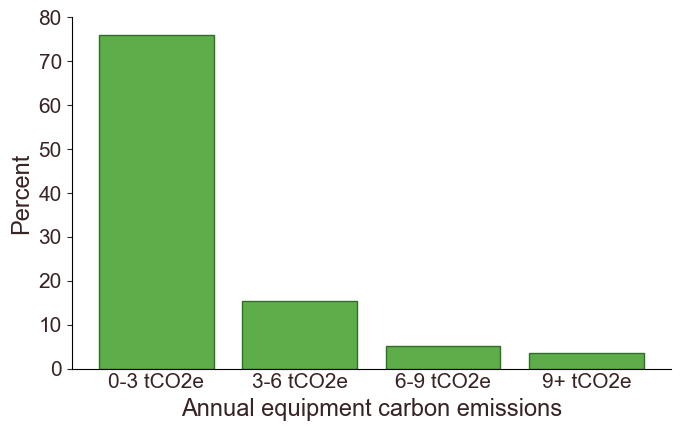

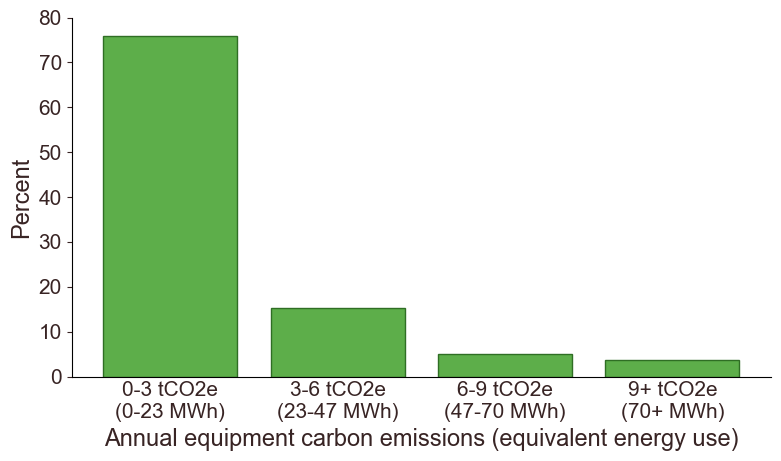

In [6]:
# Plot total emissions + energy-equivalent variants

# Keep rows with both variables available
data = labs[["calc_total_energy_mwh", "calc_total_co2"]].dropna().copy()

# CO2 per MWh
co2_per_mwh = 0.128

# Color palette
poster_main = "#5DAE4A"
poster_accent = "#0E2F4F"
poster_edge = "#2F6E24"
poster_text = "#382424"

# Plot typography
plot_font = "Arial"
plt.rcParams["font.family"] = plot_font
plt.rcParams["font.size"] = 13

# Set font sizes
axis_title_size = 17
tick_label_size = 15

output_folder = config.OUTPUT / "2_Histograms"
output_folder.mkdir(parents=True, exist_ok=True)

# Keep axis lines, remove only top/right box lines
def remove_plot_box(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# Version 1: detailed histogram for CO2
co2_bin_width = 1
bins = np.arange(0, data["calc_total_co2"].max() + co2_bin_width, co2_bin_width)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(
    data["calc_total_co2"],
    bins=bins,
    weights=np.ones(len(data)) * 100 / len(data),
    color=poster_main,
    edgecolor=poster_edge
)
ax.set_xlabel("Annual equipment carbon emissions (tCO2e)", color=poster_text)
ax.set_ylabel("Percent", color=poster_text)
ax.tick_params(colors=poster_text, labelsize=12)
ax.set_ylim(0, 50)
ax.set_yticks(np.arange(0, 51, 10))

remove_plot_box(ax)

plt.tight_layout()
plt.savefig(output_folder / "calc_total_co2.pdf")
plt.close()

# Version 2: detailed histogram for CO2 with energy equivalent axis on top
co2_bin_width = 1
bins = np.arange(0, data["calc_total_co2"].max() + co2_bin_width, co2_bin_width)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(
    data["calc_total_co2"],
    bins=bins,
    weights=np.ones(len(data)) * 100 / len(data),
    color=poster_main,
    edgecolor=poster_edge
)
ax.set_xlabel("Annual equipment carbon emissions (tCO2e)", color=poster_text, fontsize=axis_title_size)
ax.set_ylabel("Percent", color=poster_text, fontsize=axis_title_size)

secax = ax.secondary_xaxis(
    "top",
    functions=(lambda x: x / co2_per_mwh, lambda x: x * co2_per_mwh)
)
secax.set_xlabel("Equivalent energy use (MWh)", color=poster_text, fontsize=axis_title_size)

ax.tick_params(colors=poster_text, labelsize=tick_label_size)
secax.tick_params(colors=poster_text, labelsize=tick_label_size)
ax.set_ylim(0, 50)
ax.set_yticks(np.arange(0, 51, 10))

remove_plot_box(ax)

ax.text(
    0.98,
    0.95,
    f"Carbon intensity: 1 MWh = {co2_per_mwh:.3f} tCO2",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    color=poster_text,
    bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none"}
)

plt.tight_layout()
plt.savefig(output_folder / "calc_total_co2_energy.pdf")
plt.close()

# Version 3: group into CO2 categories (0-3, 3-6, 6-9, 9+ tCO2e)
co2_edges = [0, 3, 6, 9, np.inf]
co2_labels = [
    f"0-{3} tCO2e",
    f"{3}-{6} tCO2e",
    f"{6}-{9} tCO2e",
    f"{9}+ tCO2e",
]

data["co2_group"] = pd.cut(
    data["calc_total_co2"],
    bins=co2_edges,
    labels=co2_labels,
    right=False,
    include_lowest=True
)

grouped_pct = (
    data["co2_group"]
    .value_counts(normalize=True, sort=False)
    .reindex(co2_labels)
    .fillna(0)
    * 100
)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(grouped_pct.index.astype(str), grouped_pct.values, color=poster_main, edgecolor=poster_edge)
ax.set_xlabel("Annual equipment carbon emissions", color=poster_text, fontsize=axis_title_size)
ax.set_ylabel("Percent", color=poster_text, fontsize=axis_title_size)
ax.tick_params(axis="x", colors=poster_text, labelsize=tick_label_size, length=0)
ax.tick_params(axis="y", colors=poster_text, labelsize=tick_label_size)
ax.set_ylim(0, 80)
ax.set_yticks(np.arange(0, 81, 10))
remove_plot_box(ax)
plt.tight_layout()
plt.savefig(output_folder / "calc_total_co2_grouped.pdf")
plt.show()
plt.close()

# Version 4: grouped CO2 categories, with equivalent energy ranges in labels

# Calculate equivalent energy ranges for each CO2 category
energy_edges = [edge / co2_per_mwh for edge in co2_edges]
energy_labels = [
    f"0-{energy_edges[1]:.0f} MWh",
    f"{energy_edges[1]:.0f}-{energy_edges[2]:.0f} MWh",
    f"{energy_edges[2]:.0f}-{energy_edges[3]:.0f} MWh",
    f"{energy_edges[3]:.0f}+ MWh"
]

co2_to_energy_labels = [
    f"0-{3} tCO2e\n({energy_labels[0]})",
    f"{3}-{6} tCO2e\n({energy_labels[1]})",
    f"{6}-{9} tCO2e\n({energy_labels[2]})",
    f"{9}+ tCO2e\n({energy_labels[3]})",
]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(range(len(grouped_pct)), grouped_pct.values, color=poster_main, edgecolor=poster_edge)
ax.set_xticks(range(len(grouped_pct)))
ax.set_xticklabels(co2_to_energy_labels)
ax.set_xlabel("Annual equipment carbon emissions (equivalent energy use)", color=poster_text, fontsize=axis_title_size)
ax.set_ylabel("Percent", color=poster_text, fontsize=axis_title_size)
ax.tick_params(axis="x", colors=poster_text, labelsize=tick_label_size, length=0)
ax.tick_params(axis="y", colors=poster_text, labelsize=tick_label_size)
ax.set_ylim(0, 80)
ax.set_yticks(np.arange(0, 81, 10))
remove_plot_box(ax)
plt.tight_layout()
plt.savefig(output_folder / "calc_total_co2_grouped_energy.pdf")
plt.show()
plt.close()

In [7]:
# Print average carbon emissions by non_it_equipment
print("Average annual carbon emissions (tCO2e) by equipment type:")
print(labs.groupby("non_it_equipment")["calc_total_co2"].mean())

# Print average carbon emissions by faculty
print("Average annual carbon emissions (tCO2e) by faculty:")
print(labs.groupby("faculty")["calc_total_co2"].mean())

# Overall average carbon emissions
print("Average annual carbon emissions for all labs:")
print(labs["calc_total_co2"].mean())

Average annual carbon emissions (tCO2e) by equipment type:
non_it_equipment
0    0.705600
1    3.486897
Name: calc_total_co2, dtype: float64
Average annual carbon emissions (tCO2e) by faculty:
faculty
Both MNF and MeF             6.180000
Faculty of Medicine (MeF)    4.491562
Faculty of Science (MNF)     1.547449
Name: calc_total_co2, dtype: float64
Average annual carbon emissions for all labs:
2.471824817518248
